**1. IMPORTS & SETUP**

In [2]:
import os, random, warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

2026-04-20 05:19:41.582674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776662381.821430      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776662381.889304      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776662382.413544      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776662382.413590      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776662382.413593      55 computation_placer.cc:177] computation placer alr

**2. DATASET AUTO-DETECTION (KAGGLE INPUT)**

In [3]:
# -- 1. AUTO-DETECT DATASET PATH (FIX) -----------------------
import os

BASE_INPUT = "/kaggle/input"

print("Available datasets in /kaggle/input:")
print(os.listdir(BASE_INPUT))

DATASET_FOLDER = None

for root, dirs, files in os.walk(BASE_INPUT):
    if "Training" in dirs and "Testing" in dirs:
        DATASET_FOLDER = root
        break

if DATASET_FOLDER is None:
    raise FileNotFoundError("Could not auto-detect dataset folder")

print("Using dataset:", DATASET_FOLDER)

TRAIN_DIR = os.path.join(DATASET_FOLDER, "Training")
TEST_DIR  = os.path.join(DATASET_FOLDER, "Testing")

Available datasets in /kaggle/input:
['datasets']
Using dataset: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset


**3. CONFIGURATION**

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

IMAGE_SIZE = 224
BATCH_SIZE = 64
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

AUTOTUNE = tf.data.AUTOTUNE

**4. LOAD DATA**

In [5]:
def load_data(directory):
    paths, labels = [], []
    for label in CLASSES:
        folder = os.path.join(directory, label)
        for fname in os.listdir(folder):
            if fname.endswith((".jpg", ".png", ".jpeg")):
                paths.append(os.path.join(folder, fname))
                labels.append(CLASSES.index(label))
    return np.array(paths), np.array(labels)

train_paths, train_labels = load_data(TRAIN_DIR)
test_paths, test_labels = load_data(TEST_DIR)

print("Train:", len(train_paths), "Test:", len(test_paths))

Train: 5600 Test: 1600


**5. TRAIN / VALIDATION SPLIT + CLASS WEIGHTS**

In [6]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, val_idx = next(sss.split(train_paths, train_labels))

tr_paths, tr_labels = train_paths[train_idx], train_labels[train_idx]
val_paths, val_labels = train_paths[val_idx], train_labels[val_idx]

cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(tr_labels),
    y=tr_labels
)
class_weights = dict(enumerate(cw))

**6. DATA PIPELINE (PREPROCESS + AUGMENT)**

In [7]:
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, label

def augment(path, label):
    img, label = preprocess(path, label)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.rot90(img, tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label

def make_ds(paths, labels, aug=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if aug:
        ds = ds.shuffle(len(paths))
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(tr_paths, tr_labels, aug=True)
val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)

I0000 00:00:1776662411.840817      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


**7. MODEL (VGG16 TRANSFER LEARNING)**

In [8]:
base = VGG16(include_top=False, weights='imagenet',
             input_shape=(224, 224, 3))
base.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**8. TRAINING PHASE 1 (FROZEN BASE)**

In [9]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15


I0000 00:00:1776662418.142240     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.5969 - loss: 1.5093 - val_accuracy: 0.8464 - val_loss: 0.4146
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.8217 - loss: 0.4917 - val_accuracy: 0.8714 - val_loss: 0.3572
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.8301 - loss: 0.4280 - val_accuracy: 0.8768 - val_loss: 0.3231
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.8560 - loss: 0.3897 - val_accuracy: 0.8804 - val_loss: 0.3157
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.8695 - loss: 0.3318 - val_accuracy: 0.8821 - val_loss: 0.3170
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8715 - loss: 0.3196 - val_accuracy: 0.8714 - val_loss: 0.3028
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8727 - loss: 0.3279 - val_accuracy: 0.8946 - val_loss: 0.2686
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8882 - loss: 0.2899 - val_accuracy: 0.892

**9. FINE TUNING (UNFREEZE TOP LAYERS)**

In [10]:
base.trainable = True
for layer in base.layers:
    layer.trainable = layer.name.startswith("block5")

model.compile(
    optimizer=Adam(5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8941 - loss: 0.2811 - val_accuracy: 0.9196 - val_loss: 0.2033
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9365 - loss: 0.1697 - val_accuracy: 0.9268 - val_loss: 0.1847
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.9475 - loss: 0.1333 - val_accuracy: 0.9393 - val_loss: 0.1553
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9578 - loss: 0.1188 - val_accuracy: 0.9429 - val_loss: 0.1396
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9689 - loss: 0.0899 - val_accuracy: 0.9589 - val_loss: 0.1200
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9764 - loss: 0.0761 - val_accuracy: 0.9500 - val_loss: 0.1396
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - accuracy: 0.9800 - loss: 0.0610 - val_accuracy: 0.9589 - val_loss: 0.1112
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9794 - loss: 0.0552 - val_accu

**10. EVALUATION**

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step
              precision    recall  f1-score   support

      glioma       1.00      0.79      0.88       400
  meningioma       0.86      0.98      0.92       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



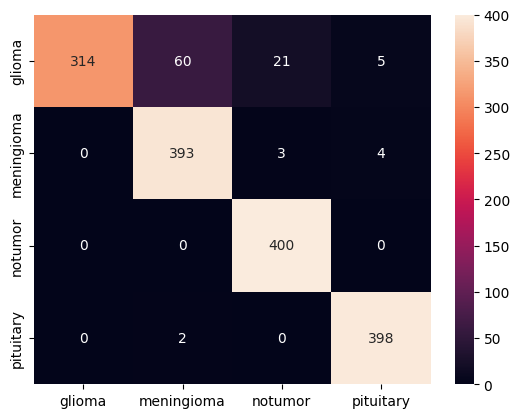

In [11]:
pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(test_labels, pred, target_names=CLASSES))

cm = confusion_matrix(test_labels, pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.show()

**11. Save Model**

In [12]:
SAVE_PATH = "brain_tumor_model.h5"

# Save model
model.save(SAVE_PATH)
print("Model saved:", SAVE_PATH)

# Reload (sanity check like Colab)
reloaded = tf.keras.models.load_model(SAVE_PATH, compile=False)

print("Reloaded model.input  :", reloaded.input)
print("Reloaded model.output :", reloaded.output)
print("✅ Reload verified — Grad-CAM will work in Flask")

# Download (Kaggle version of files.download)
from IPython.display import FileLink

FileLink(SAVE_PATH)

Model saved: brain_tumor_model.h5
Reloaded model.input  : [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]
Reloaded model.output : <KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_73>
✅ Reload verified — Grad-CAM will work in Flask


/kaggle/working/brain_tumor_model.h5